In [1]:
import os
import shutil

# Tạo thư mục data nếu chưa có
os.makedirs('data', exist_ok=True)

# Đưa tệp sinh_vien.csv vào thư mục data để khớp với đường dẫn trong tài liệu
if os.path.exists('sinh_vien.csv') and not os.path.exists('data/sinh_vien.csv'):
    shutil.move('sinh_vien.csv', 'data/sinh_vien.csv')

print("Đã chuẩn bị xong thư mục và dữ liệu![cite: 1]")

Đã chuẩn bị xong thư mục và dữ liệu![cite: 1]


In [4]:
import pandas as pd

# Đọc bộ dữ liệu từ thư mục data[cite: 1]
df = pd.read_csv("sinh_vien.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

# Cột qua_mon chỉ có hai giá trị, đếm số lần xuất hiện từng giá trị[cite: 1]
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()

print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

# So sánh số giờ ôn trung bình của hai nhóm[cite: 1]
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


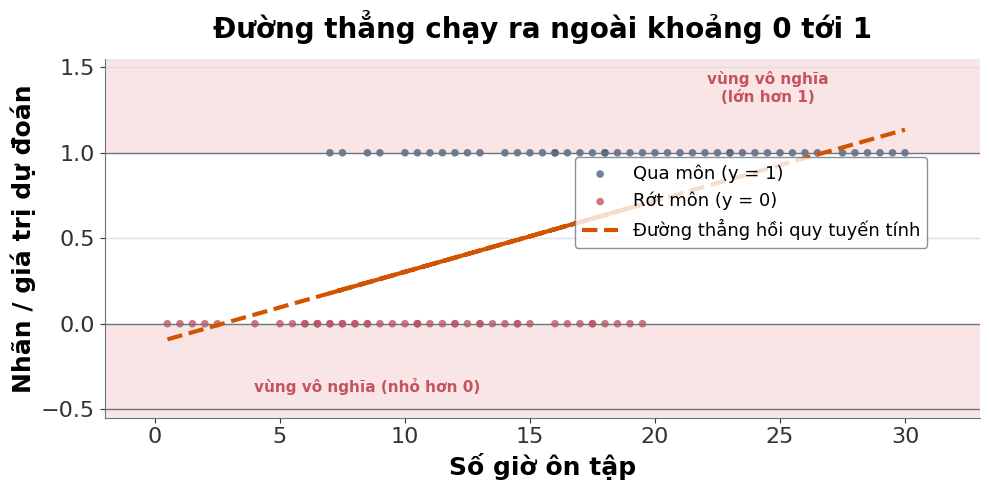

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.font_manager as fm
fm.findfont("DejaVu Sans") # Đặt font mặc định để hiển thị tiếng Việt tốt trên Colab

# Tạo dữ liệu mô phỏng dựa trên hình ảnh gốc (đã được làm sạch cho phù hợp với code)
# Chúng ta sẽ tạo ra một DataFrame giả lập chứa số giờ ôn tập (x) và nhãn qua/rớt (y)
# Nhãn 1: Qua môn (xanh), Nhãn 0: Rớt môn (đỏ)
data = {
    'gio_on': [0.5, 1.0, 1.5, 2.0, 2.5, 4.0, 5.0, 5.5, 6.0, 6.0, 6.5, 6.5, 6.5, 7.0, 7.0, 7.5, 7.5, 8.0, 8.0, 8.5, 8.5, 9.0, 9.5, 10.0, 10.5, 10.5, 10.5, 11.0, 11.5, 12.0, 12.0, 12.5, 13.0, 13.0, 13.5, 14.0, 14.5, 14.5, 15.0, 16.0, 16.5, 17.0, 17.5, 17.5, 18.0, 18.5, 19.0, 19.5, 7.0, 7.5, 8.5, 9.0, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 14.0, 14.5, 15.0, 15.5, 16.0, 16.0, 16.5, 17.0, 17.5, 18.0, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0],
    'qua_mon': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

# Tách dữ liệu thành 2 nhóm để dễ vẽ màu
df_rot = df[df['qua_mon'] == 0]
df_qua = df[df['qua_mon'] == 1]

# Khớp mô hình hồi quy tuyến tính (Linear Regression)
X = df[['gio_on']]
y = df['qua_mon']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Tạo hình và thiết lập các trục
fig, ax = plt.subplots(figsize=(10, 5))

# 1. Tô nền vùng vô nghĩa
# Vùng > 1
ax.axhspan(1, 1.55, facecolor='#f4cccc', alpha=0.5)
# Vùng < 0
ax.axhspan(-0.55, 0, facecolor='#f4cccc', alpha=0.5)

# 2. Vẽ các đường lưới ngang
ax.axhline(y=0, color='#6c757d', linestyle='-', linewidth=1)
ax.axhline(y=0.5, color='#e0e0e0', linestyle='-', linewidth=1)
ax.axhline(y=1, color='#6c757d', linestyle='-', linewidth=1)
ax.axhline(y=1.5, color='#e0e0e0', linestyle='-', linewidth=1)
ax.axhline(y=-0.5, color='#6c757d', linestyle='-', linewidth=1)

# 3. Vẽ các điểm dữ liệu thực tế
# Nhóm rớt môn (màu đỏ)
ax.scatter(df_rot['gio_on'], df_rot['qua_mon'], color='#c6525f', label='Rớt môn (y = 0)', s=30, edgecolors='none', alpha=0.8)
# Nhóm qua môn (màu xanh)
ax.scatter(df_qua['gio_on'], df_qua['qua_mon'], color='#4f627d', label='Qua môn (y = 1)', s=30, edgecolors='none', alpha=0.8)

# 4. Vẽ đường thẳng hồi quy tuyến tính (đứt nét, màu cam)
ax.plot(X['gio_on'], y_pred, color='#d35400', linestyle='--', linewidth=3, label='Đường thẳng hồi quy tuyến tính')

# 5. Thêm văn bản chú thích cho vùng vô nghĩa
ax.text(24.5, 1.3, 'vùng vô nghĩa\n(lớn hơn 1)', color='#c6525f', fontweight='bold', ha='center', fontsize=11)
ax.text(8.5, -0.4, 'vùng vô nghĩa (nhỏ hơn 0)', color='#c6525f', fontweight='bold', ha='center', fontsize=11)

# 6. Tùy chỉnh tiêu đề và nhãn trục
ax.set_title('Đường thẳng chạy ra ngoài khoảng 0 tới 1', fontsize=20, fontweight='bold', pad=15)
ax.set_xlabel('Số giờ ôn tập', fontsize=18, fontweight='bold')
ax.set_ylabel('Nhãn / giá trị dự đoán', fontsize=18, fontweight='bold')

# 7. Tùy chỉnh thang đo trục
ax.set_xlim(-2, 33)
ax.set_ylim(-0.55, 1.55)
ax.set_yticks([-0.5, 0, 0.5, 1.0, 1.5])

# 8. Tùy chỉnh các đường viền hộp
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6c757d')
ax.spines['bottom'].set_color('#6c757d')
ax.tick_params(axis='both', colors='#333333', labelsize=16)

# 9. Thêm chú thích (legend)
# Lấy handles và labels hiện có
handles, labels = ax.get_legend_handles_labels()
# Tạo custom legend để giữ thứ tự hiển thị như ảnh
order = [1, 0, 2] # Vị trí mới của các item: Qua môn, Rớt môn, Đường thẳng
ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order], loc='center right', bbox_to_anchor=(0.95, 0.6), frameon=True, edgecolor='#6c757d', fontsize=13)

# 10. Hiển thị biểu đồ
plt.tight_layout()
plt.show()

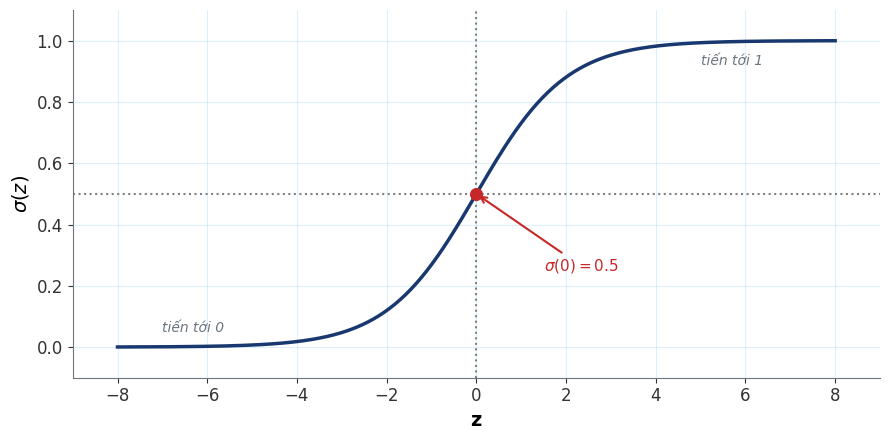

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Tạo dãy giá trị z từ -8 đến 8
z = np.linspace(-8, 8, 400)

# Tính giá trị hàm sigmoid
sigma_z = 1 / (1 + np.exp(-z))

# Khởi tạo khung hình
fig, ax = plt.subplots(figsize=(9, 4.5))

# 1. Vẽ đường cong Sigmoid (màu xanh đậm)
ax.plot(z, sigma_z, color='#18386f', linewidth=2.5)

# 2. Vẽ các đường lưới định vị tại điểm z = 0 và sigma(z) = 0.5
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5)
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.5)

# 3. Đánh dấu điểm đặc biệt tại z = 0, sigma(0) = 0.5 (chấm tròn đỏ)
ax.scatter([0], [0.5], color='#c62828', s=70, zorder=5)

# 4. Thêm chú thích mũi tên chỉ vào điểm (0, 0.5)
ax.annotate('$\\sigma(0) = 0.5$',
            xy=(0, 0.5), xytext=(1.5, 0.25),
            arrowprops=dict(arrowstyle='->', color='#c62828', lw=1.5),
            color='#c62828', fontweight='bold', fontsize=11)

# 5. Thêm chữ "tiến tới 0" và "tiến tới 1" ở hai đầu đường cong
ax.text(-7, 0.05, 'tiến tới 0', color='#6c757d', fontstyle='italic', fontsize=10)
ax.text(5, 0.92, 'tiến tới 1', color='#6c757d', fontstyle='italic', fontsize=10)

# 6. Thiết lập giới hạn trục và nhãn
ax.set_xlim(-9, 9)
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel('$\\sigma(z)$', fontsize=14, fontweight='bold')
ax.set_xlabel('$\\mathbf{z}$', fontsize=14, fontweight='bold')

# 7. Tinh chỉnh khung viền giống phong cách tối giản
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6c757d')
ax.spines['bottom'].set_color('#6c757d')
ax.tick_params(axis='both', colors='#333333', labelsize=12)
ax.grid(True, linestyle='-', alpha=0.3, color='#90caf9')

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

def sigmoid(z):
    """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
    return 1 / (1 + np.exp(-z))

print("Bang gia tri cua ham sigmoid")
print("   z    sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}    {sigmoid(z):.4f}")
print()

# Kiểm chứng tính chất sigmoid(-z) = 1 - sigmoid(z)[cite: 1]
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
    trai = sigmoid(-z)
    phai = 1 - sigmoid(z)
    print(f"  z={z}: {trai:.6f} va {phai:.6f}")
print()

# Thử với một mô hình giả định w = 0.4 và b = -5[cite: 1]
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w={w}, b={b}")
print(" So gio on    z = w*x + b    Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f" {gio:5.1f}      {z:6.2f}          {sigmoid(z):.4f}")

Bang gia tri cua ham sigmoid
   z    sigmoid(z)
 -6    0.0025
 -4    0.0180
 -2    0.1192
 -1    0.2689
  0    0.5000
  1    0.7311
  2    0.8808
  4    0.9820
  6    0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
  z=1.0: 0.268941 va 0.268941
  z=2.5: 0.075858 va 0.075858
  z=3.7: 0.024127 va 0.024127

Mo hinh gia dinh: w=0.4, b=-5.0
 So gio on    z = w*x + b    Xac suat qua mon
   5.0       -3.00          0.0474
  10.0       -1.00          0.2689
  12.5        0.00          0.5000
  15.0        1.00          0.7311
  20.0        3.00          0.9526
  25.0        5.00          0.9933


In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("sinh_vien.csv")

# X phải là bảng hai chiều nên viết hai cặp ngoặc vuông.[cite: 1]
# y là dãy một chiều nên chỉ một cặp.[cite: 1]
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()

# Số giờ ôn mà mô hình phân vân đúng năm mươi năm mươi[cite: 1]
print(f"So gio on ung voi xac suat 0.5: {-b/w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)

print("Du doan cho nam ban moi:")
print(" So gio on    Xac suat qua    Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
    print(f" {gio:5.1f}         {p:.4f}             {n}")

He so goc w = 0.392819
He so chan b = -5.064890

So gio on ung voi xac suat 0.5: 12.89 gio

Du doan cho nam ban moi:
 So gio on    Xac suat qua    Nhan mo hinh dua ra
   5.0         0.0431             0
  10.0         0.2429             0
  13.0         0.5104             1
  20.0         0.9422             1
  28.0         0.9974             1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


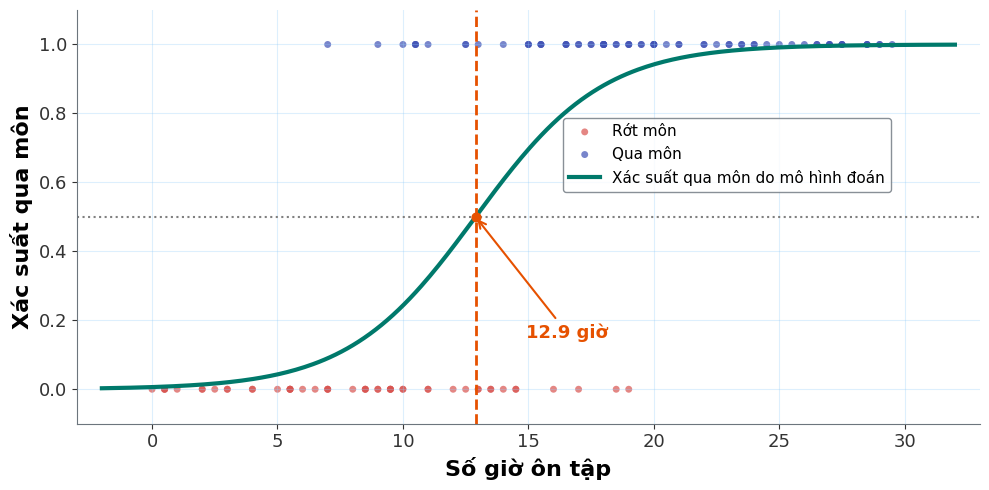

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Đọc dữ liệu từ tệp
df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# 2. Huấn luyện mô hình Logistic Regression
model = LogisticRegression()
model.fit(X, y)

# Tách dữ liệu thành nhóm rớt và qua môn
df_rot = df[df["qua_mon"] == 0]
df_qua = df[df["qua_mon"] == 1]

# Tạo dải giá trị giờ ôn để vẽ đường cong sigmoid mịn màng
x_range = np.linspace(-2, 32, 300).reshape(-1, 1)
y_prob = model.predict_proba(x_range)[:, 1]

# 3. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(10, 5))

# Vẽ đường lưới nền
ax.grid(True, linestyle='-', alpha=0.3, color='#90caf9')

# 4. Vẽ các điểm dữ liệu thực tế
ax.scatter(df_rot["gio_on"], df_rot["qua_mon"], color='#d9534f', label='Rớt môn', s=25, alpha=0.7, edgecolors='none')
ax.scatter(df_qua["gio_on"], df_qua["qua_mon"], color='#3f51b5', label='Qua môn', s=25, alpha=0.7, edgecolors='none')

# 5. Vẽ đường cong xác suất hồi quy logistic (màu xanh đậm)
ax.plot(x_range, y_prob, color='#00796b', linewidth=3, label='Xác suất qua môn do mô hình đoán')

# 6. Vẽ đường thẳng đứt nét màu cam tại mốc xác suất 0.5 (khoảng 12.9 giờ)
threshold_x = -model.intercept_[0] / model.coef_[0][0] # Tính chính xác điểm 0.5 (~12.9)
ax.axvline(x=threshold_x, color='#e65100', linestyle='--', linewidth=2)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5)

# 7. Đánh dấu điểm giao và chú thích "12.9 giờ"
ax.scatter([threshold_x], [0.5], color='#e65100', s=40, zorder=5)
ax.annotate('12.9 giờ',
            xy=(threshold_x, 0.5), xytext=(threshold_x + 2, 0.15),
            arrowprops=dict(arrowstyle='->', color='#e65100', lw=1.5),
            color='#e65100', fontweight='bold', fontsize=13)

# 8. Tùy chỉnh nhãn và tiêu đề trục
ax.set_xlabel('Số giờ ôn tập', fontsize=16, fontweight='bold')
ax.set_ylabel('Xác suất qua môn', fontsize=16, fontweight='bold')

# 9. Giới hạn thang đo
ax.set_xlim(-3, 33)
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# 10. Tùy chỉnh khung viền tối giản
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6c757d')
ax.spines['bottom'].set_color('#6c757d')
ax.tick_params(axis='both', colors='#333333', labelsize=13)

# 11. Thêm bảng chú thích (legend)
ax.legend(loc='center right', bbox_to_anchor=(0.91, 0.65), frameon=True, edgecolor='#6c757d', fontsize=11)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# stratify=y giữ đúng tỷ lệ qua và rớt ở cả hai phần sau khi chia[cite: 1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc      :", len(X_train))
print("So sinh vien de kiem tra :", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP[cite: 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan:")
print(f"  TN = {tn:2d}  (doan rot, that su rot)")
print(f"  FP = {fp:2d}  (doan qua, that ra rot)")
print(f"  FN = {fn:2d}  (doan rot, that ra qua)")
print(f"  TP = {tp:2d}  (doan qua, that su qua)")
print()

print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")
print()

# Tự tính lại bằng tay để đối chiếu với thư viện[cite: 1]
print("Tu tinh lai bang cong thuc:")
n = len(y_test)
print(f"  Accuracy  = ({tp} + {tn}) / {n} = {(tp + tn) / n:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")

So sinh vien de hoc      : 90
So sinh vien de kiem tra : 30

Ma tran nham lan:
  TN =  9  (doan rot, that su rot)
  FP =  3  (doan qua, that ra rot)
  FN =  1  (doan rot, that ra qua)
  TP = 17  (doan qua, that su qua)

Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947

Tu tinh lai bang cong thuc:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444


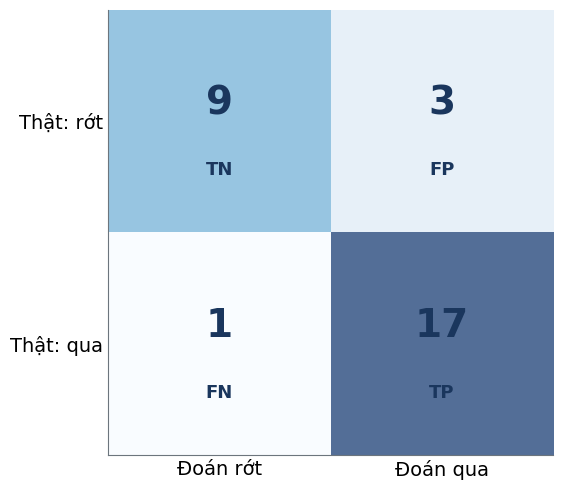

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Chuẩn bị dữ liệu và huấn luyện mô hình giống hệt các bước trước
df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# 2. Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
# cm trả về ma trận: [[TN, FP], [FN, TP]] = [[9, 3], [1, 17]]
tn, fp, fn, tp = cm.ravel()

# 3. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(6, 5))

# Tạo bảng dữ liệu ma trận trực quan bằng imshow với tông màu xanh nhạt/đậm
matrix_data = np.array([[tn, fp], [fn, tp]])
cax = ax.imshow(matrix_data, cmap='Blues', alpha=0.7, interpolation='nearest')

# 4. Gắn các giá trị số lượng và tên mãnh (TN, FP, FN, TP) vào từng ô
annot = [
    [[str(tn), 'TN'], [str(fp), 'FP']],
    [[str(fn), 'FN'], [str(tp), 'TP']]
]

for i in range(2):
    for j in range(2):
        val, label = annot[i][j]
        # Chữ số to ở trên
        ax.text(j, i - 0.08, val, ha='center', va='center',
                fontsize=28, fontweight='bold', color='#1a365d')
        # Chữ ký hiệu (TN, FP, FN, TP) nhỏ ở dưới
        ax.text(j, i + 0.22, label, ha='center', va='center',
                fontsize=13, fontweight='semibold', color='#1a365d')

# 5. Tùy chỉnh nhãn trục tọa độ
ax.set_xticks([0, 1])
ax.set_xticklabels(['Đoán rớt', 'Đoán qua'], fontsize=14)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Thật: rớt', 'Thật: qua'], fontsize=14)

# Đưa nhãn trục X lên trên hoặc để dưới theo ý thích (ở đây để mặc định dưới)
ax.xaxis.tick_bottom()

# 6. Tùy chỉnh khung viền
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6c757d')
ax.spines['bottom'].set_color('#6c757d')

# 7. Loại bỏ các vạch tick thừa
ax.tick_params(axis='both', length=0)

plt.tight_layout()
plt.show()

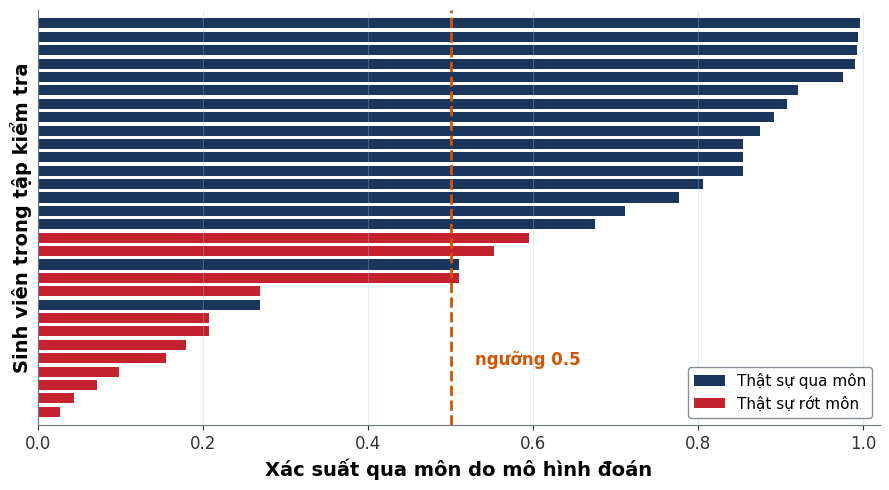

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Huấn luyện mô hình và lấy xác suất trên tập kiểm tra
df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

# Tính xác suất qua môn của tập test
probs = mo_hinh.predict_proba(X_test)[:, 1]

# Sắp xếp theo thứ tự xác suất tăng dần để biểu đồ đẹp mắt từ thấp lên cao
sorted_idx = np.argsort(probs)
sorted_probs = probs[sorted_idx]
sorted_y_test = y_test.values[sorted_idx]

# 2. Khởi tạo biểu đồ cột ngang
fig, ax = plt.subplots(figsize=(9, 5))

# Vẽ đường lưới nền dọc
ax.grid(True, axis='x', linestyle='-', alpha=0.3, color='#90caf9')

# 3. Phân chia màu cột: Xanh đậm nếu thực sự qua môn (y=1), Đỏ nếu thực sự rớt môn (y=0)
colors = ['#1a365d' if label == 1 else '#c5222f' for label in sorted_y_test]
y_pos = np.arange(len(sorted_probs))

ax.barh(y_pos, sorted_probs, color=colors, height=0.75, edgecolor='none')

# 4. Vẽ đường ranh giới ngưỡng 0.5 (đường đứt nét màu cam)
ax.axvline(x=0.5, color='#d35400', linestyle='--', linewidth=2)

# Chú thích chữ "ngưỡng 0.5"
ax.text(0.53, 3.5, 'ngưỡng 0.5', color='#d35400', fontweight='bold', fontsize=12)

# 5. Tùy chỉnh nhãn trục và tiêu đề
ax.set_xlabel('Xác suất qua môn do mô hình đoán', fontsize=14, fontweight='bold')
ax.set_ylabel('Sinh viên trong tập kiểm tra', fontsize=14, fontweight='bold')

# Ẩn nhãn số ở trục Y vì danh sách sinh viên ẩn danh
ax.set_yticks([])

# 6. Thiết lập giới hạn
ax.set_xlim(0, 1.02)
ax.set_ylim(-1, len(sorted_probs))

# 7. Tùy chỉnh khung viền tối giản
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6c757d')
ax.spines['bottom'].set_color('#6c757d')
ax.tick_params(axis='x', colors='#333333', labelsize=12)

# 8. Tạo bảng chú thích (legend) tùy chỉnh
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1a365d', label='Thật sự qua môn'),
    Patch(facecolor='#c5222f', label='Thật sự rớt môn')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, edgecolor='#6c757d', fontsize=11)

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

# predict_proba trả về hai cột, cột 0 cho lớp 0 và cột 1 cho lớp 1[cite: 1]
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong    So ban bi doan la qua    Precision    Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred = (p >= nguong).astype(int)
    pre = precision_score(y_test, y_pred, zero_division=1)
    rec = recall_score(y_test, y_pred, zero_division=0)
    print(f" {nguong:5.1f}          {y_pred.sum():3d}             {pre:.4f}     {rec:.4f}")

print()
print("Doc bang tren tu duoi len:")
print(" Nguong cang cao thi mo hinh cang kho tinh,")
print(" precision tang nhung recall giam. Nguong thap thi nguoc lai.")

Nguong    So ban bi doan la qua    Precision    Recall
   0.2           24             0.7500     1.0000
   0.3           20             0.8500     0.9444
   0.4           20             0.8500     0.9444
   0.5           20             0.8500     0.9444
   0.6           16             1.0000     0.8889
   0.7           15             1.0000     0.8333
   0.8           13             1.0000     0.7222

Doc bang tren tu duoi len:
 Nguong cang cao thi mo hinh cang kho tinh,
 precision tang nhung recall giam. Nguong thap thi nguoc lai.


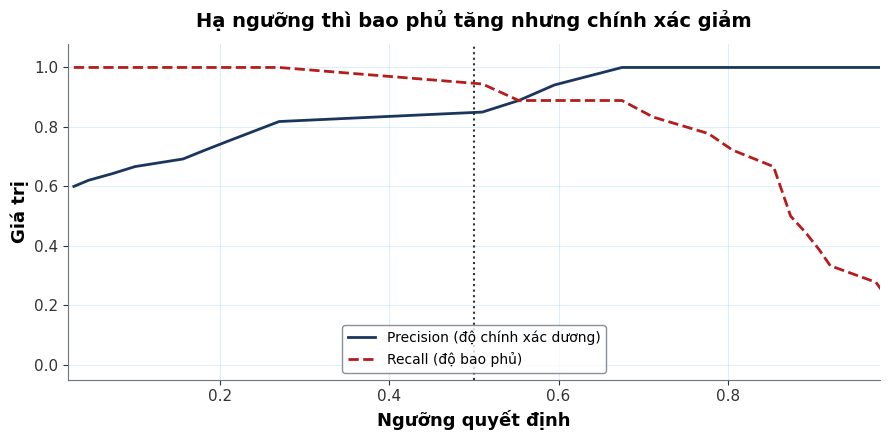

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

# 1. Huấn luyện mô hình và lấy xác suất dự đoán trên tập kiểm tra
df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

# 2. Quét qua các ngưỡng quyết định độc lập từ xác suất dự đoán
thresholds = np.sort(np.unique(p))
precisions = []
recalls = []

for th in thresholds:
    y_pred = (p >= th).astype(int)
    pre = precision_score(y_test, y_pred, zero_division=1)
    rec = recall_score(y_test, y_pred, zero_division=0)
    precisions.append(pre)
    recalls.append(rec)

# 3. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(9, 4.5))

# Vẽ đường lưới nền
ax.grid(True, linestyle='-', alpha=0.3, color='#90caf9')

# 4. Vẽ đường Precision (màu xanh đậm) và Recall (đường đứt nét màu đỏ)
ax.plot(thresholds, precisions, color='#1a365d', linewidth=2, label='Precision (độ chính xác dương)')
ax.plot(thresholds, recalls, color='#b71c1c', linestyle='--', linewidth=2, label='Recall (độ bao phủ)')

# 5. Vẽ đường kẻ dọc tại ngưỡng mặc định 0.5
ax.axvline(x=0.5, color='#333333', linestyle=':', linewidth=1.5)

# 6. Tùy chỉnh tiêu đề và nhãn trục
ax.set_title('Hạ ngưỡng thì bao phủ tăng nhưng chính xác giảm', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Ngưỡng quyết định', fontsize=13, fontweight='bold')
ax.set_ylabel('Giá trị', fontsize=13, fontweight='bold')

# 7. Thiết lập giới hạn
ax.set_xlim(0.02, 0.98)
ax.set_ylim(-0.05, 1.08)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# 8. Tùy chỉnh khung viền tối giản
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6c757d')
ax.spines['bottom'].set_color('#6c757d')
ax.tick_params(axis='both', colors='#333333', labelsize=11)

# 9. Thêm bảng chú thích (legend)
ax.legend(loc='lower center', frameon=True, edgecolor='#6c757d', fontsize=10)

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
y = df["qua_mon"]

# So sánh accuracy giữa 1 biến và 2 biến[cite: 1]
for ten, cot in [("Mot bien", ["gio_on"]), ("Hai bien", ["gio_on", "diem_giua_ky"])]:
    X = df[cot]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=17, stratify=y
    )
    mo_hinh = LogisticRegression().fit(X_train, y_train)
    do_chinh_xac = accuracy_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten:10s}: accuracy tren tap kiem tra = {do_chinh_xac:.4f}")

print()

# Huấn luyện chi tiết mô hình hai biến để xem hệ số[cite: 1]
X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X.columns, mo_hinh.coef_[0]):
    print(f"  {ten_cot:14s} {he_so:+.4f}")
print(f"  {'he so chan':14s} {mo_hinh.intercept_[0]:+.4f}")
print()
print("Ca hai he so deu duong, nghia la on nhieu hon va")
print("diem giua ky cao hon deu lam tang xac suat qua mon.")

Mot bien  : accuracy tren tap kiem tra = 0.8667
Hai bien  : accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
  gio_on         +0.3035
  diem_giua_ky   +0.5885
  he so chan     -6.9811

Ca hai he so deu duong, nghia la on nhieu hon va
diem giua ky cao hon deu lam tang xac suat qua mon.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


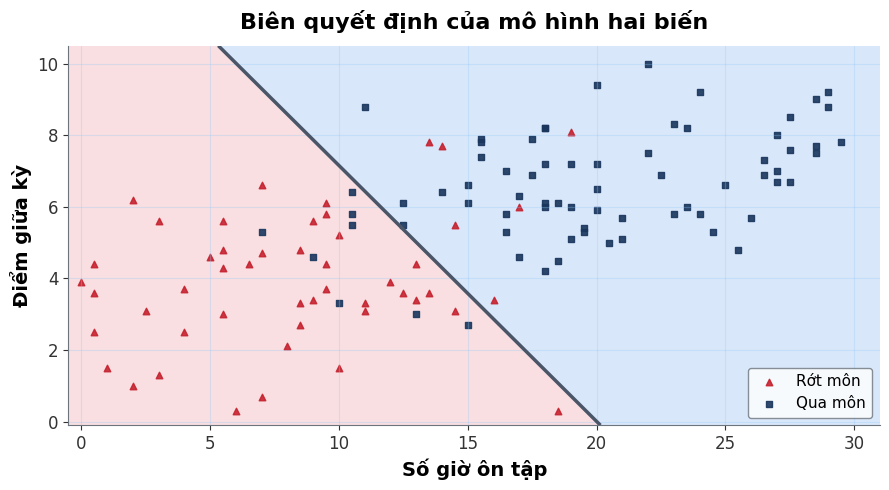

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Đọc dữ liệu và huấn luyện mô hình hai biến (gio_on, diem_giua_ky)
df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on", "diem_giua_ky"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression().fit(X, y)

# Tách dữ liệu thành nhóm rớt và qua môn
df_rot = df[df["qua_mon"] == 0]
df_qua = df[df["qua_mon"] == 1]

# 2. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(9, 5))

# Vẽ đường lưới nền nhạt
ax.grid(True, linestyle='-', alpha=0.3, color='#90caf9')

# 3. Tạo lưới không gian để tô màu phân vùng quyết định (Vùng đỏ: rớt, Vùng xanh: qua)
x_min, x_max = -0.5, 31
y_min, y_max = -0.1, 10.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]
probs = mo_hinh.predict_proba(grid_points)[:, 1].reshape(xx.shape)

# Dùng contourf để tô màu nền
ax.contourf(xx, yy, probs, levels=[0, 0.5, 1], colors=['#f8d7da', '#d0e1f9'], alpha=0.8)

# Vẽ đường biên quyết định (tại xác suất = 0.5)
ax.contour(xx, yy, probs, levels=[0.5], colors=['#4a5568'], linewidths=2.5)

# 4. Vẽ các điểm dữ liệu thực tế (Tam giác đỏ cho rớt môn, Vuông xanh đậm cho qua môn)
ax.scatter(df_rot["gio_on"], df_rot["diem_giua_ky"], color='#c5222f', marker='^', s=22, label='Rớt môn', alpha=0.9)
ax.scatter(df_qua["gio_on"], df_qua["diem_giua_ky"], color='#1a365d', marker='s', s=20, label='Qua môn', alpha=0.9)

# 5. Tiêu đề và nhãn trục
ax.set_title('Biên quyết định của mô hình hai biến', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Số giờ ôn tập', fontsize=14, fontweight='bold')
ax.set_ylabel('Điểm giữa kỳ', fontsize=14, fontweight='bold')

# 6. Thiết lập giới hạn
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_yticks([0, 2, 4, 6, 8, 10])

# 7. Tùy chỉnh khung viền
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6c757d')
ax.spines['bottom'].set_color('#6c757d')
ax.tick_params(axis='both', colors='#333333', labelsize=12)

# 8. Thêm bảng chú thích (legend)
ax.legend(loc='lower right', frameon=True, edgecolor='#6c757d', fontsize=11)

plt.tight_layout()
plt.show()